In [1]:
# Vol regime study — mirrors regime_study_v2.ipynb
# HMM on lagged_VRP only: 2-year rolling fit, daily refit, today scored OOS.
import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)

plt.rcParams.update(plt.rcParamsDefault)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

TRADING_DAYS = 252
DATA_PERIOD = "max"

TRAIN_WINDOW_DAYS = TRADING_DAYS * 2
REFIT_EVERY_DAYS = 1
LOW_VOL_PROB_THRESHOLD = 0.5
LOW_VOL_TMR_THRESHOLD = 0.5
FEATURE_COLS = ["lagged_VRP"]

LIVE_START = pd.Timestamp("2020-01-01")
LIVE_END = None

MARKETS = {
    "SPX": {"underly": "^SPX", "vol": "^VIX"},
    "DJI": {"underly": "^DJI", "vol": "^VXD"},
    "NSDQ": {"underly": "^NDX", "vol": "^VXN"},
}


def download_close(ticker: str, period: str = DATA_PERIOD) -> pd.Series:
    raw = yf.download(ticker, period=period, auto_adjust=True, progress=False)
    if raw.empty or "Close" not in raw:
        raise ValueError(f"No close data returned for {ticker}")
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    return close.astype(float)


def download_market(underly_ticker: str, vol_ticker: str) -> pd.DataFrame:
    prices = pd.concat(
        {
            "UNDERLY": download_close(underly_ticker),
            "VOL": download_close(vol_ticker),
        },
        axis=1,
        join="inner",
    ).sort_index()
    prices.index.name = "DATE"
    return prices.reset_index()


In [2]:
def build_lagged_vrp_frame(prices: pd.DataFrame) -> pd.DataFrame:
    """lagged_VRP in annualized vol % (IV and RV_22 on same scale)."""
    df = prices.copy()
    df["DATE"] = pd.to_datetime(df["DATE"])
    df = df.sort_values("DATE").reset_index(drop=True)

    df["SPX_RET"] = np.log(df["UNDERLY"] / df["UNDERLY"].shift(1))
    df["RV_22"] = df["SPX_RET"].rolling(22).std() * np.sqrt(TRADING_DAYS) * 100
    df["IV"] = df["VOL"]
    df["lagged_VRP"] = df["IV"].shift(22) - df["RV_22"]

    return df.dropna(subset=["lagged_VRP", "UNDERLY", "VOL", "SPX_RET"]).reset_index(drop=True)


frames_by_market = {}
for name, cfg in MARKETS.items():
    prices = download_market(cfg["underly"], cfg["vol"])
    frames_by_market[name] = build_lagged_vrp_frame(prices)
    sample = frames_by_market[name]
    print(
        f"{name}: {sample['DATE'].min().date()} to {sample['DATE'].max().date()} "
        f"({len(sample):,} rows)"
    )


SPX: 1990-02-01 to 2026-06-26 (9,166 rows)
DJI: 2005-12-27 to 2026-06-26 (5,152 rows)
NSDQ: 2001-02-23 to 2026-06-26 (6,372 rows)


In [3]:
def run_daily_hmm(df: pd.DataFrame) -> pd.DataFrame:
    """Daily walk-forward HMM — copied from regime_study_v2 logic."""
    live_end = LIVE_END or df["DATE"].max()
    df_model = df.set_index("DATE").loc[:live_end].copy()
    df_predict = df_model.loc[LIVE_START:].copy()
    predict_indices = df_predict.index

    daily_regimes = []
    daily_calm_probs = []
    daily_calm_tmr_probs = []

    current_model = None
    invert_labels = False
    fit_failed_count = 0

    for i, current_date in enumerate(predict_indices):
        loc_idx = df_model.index.get_loc(current_date)
        if isinstance(loc_idx, slice):
            loc_idx = loc_idx.start

        if loc_idx < TRAIN_WINDOW_DAYS:
            daily_regimes.append(0)
            daily_calm_probs.append(np.nan)
            daily_calm_tmr_probs.append(np.nan)
            continue

        if i % REFIT_EVERY_DAYS == 0 or current_model is None:
            train_data = df_model.iloc[loc_idx - TRAIN_WINDOW_DAYS : loc_idx]
            x_train = train_data[FEATURE_COLS].values
            try:
                new_model = hmm.GaussianHMM(
                    n_components=2,
                    covariance_type="diag",
                    n_iter=500,
                    tol=1e-1,
                    random_state=42,
                    transmat_prior=1.0,
                )
                new_model.fit(x_train)
                current_model = new_model
                mean_0 = current_model.means_[0][0]
                mean_1 = current_model.means_[1][0]
                invert_labels = mean_0 > mean_1
            except Exception:
                fit_failed_count += 1
                if current_model is None:
                    daily_regimes.append(0)
                    daily_calm_probs.append(np.nan)
                    daily_calm_tmr_probs.append(np.nan)
                    continue

        historical_and_today = df_model.iloc[loc_idx - TRAIN_WINDOW_DAYS + 1 : loc_idx + 1]
        x_total = historical_and_today[FEATURE_COLS].values

        try:
            probs_total = current_model.predict_proba(x_total)
            today_probs = probs_total[-1]
        except Exception:
            daily_regimes.append(0)
            daily_calm_probs.append(np.nan)
            daily_calm_tmr_probs.append(np.nan)
            continue

        if invert_labels:
            calm_idx, crisis_idx = 0, 1
        else:
            calm_idx, crisis_idx = 1, 0

        prob_calm_today = today_probs[calm_idx]
        transmat = current_model.transmat_
        prob_calm_tmr = (
            today_probs[calm_idx] * transmat[calm_idx, calm_idx]
            + today_probs[crisis_idx] * transmat[crisis_idx, calm_idx]
        )

        signal = int(
            prob_calm_today >= LOW_VOL_PROB_THRESHOLD
            and prob_calm_tmr >= LOW_VOL_TMR_THRESHOLD
        )
        daily_regimes.append(signal)
        daily_calm_probs.append(prob_calm_today)
        daily_calm_tmr_probs.append(prob_calm_tmr)

    df_predict = df_predict.copy()
    df_predict["Regime"] = daily_regimes
    df_predict["prob_low_vol"] = daily_calm_probs
    df_predict["prob_low_vol_tmr"] = daily_calm_tmr_probs
    df_predict.attrs["fit_failed_count"] = fit_failed_count
    return df_predict


results_by_market = {name: run_daily_hmm(df) for name, df in frames_by_market.items()}

output_dir = Path("Saved_Signal")
output_dir.mkdir(parents=True, exist_ok=True)

for name, df_predict in results_by_market.items():
    signal_out = df_predict.reset_index()[["DATE", "Regime"]].rename(
        columns={"DATE": "date", "Regime": "signal"}
    )
    signal_out["signal"] = signal_out["signal"].astype(int)
    # signal_out.to_csv(output_dir / f"regime_{name.lower()}.csv", index=False)

    last = df_predict.iloc[-1]
    print(f"\n{name}")
    print(f"  Features: {FEATURE_COLS} | Daily refit | window={TRAIN_WINDOW_DAYS}d")
    print(f"  Period: {LIVE_START.date()} to {df_predict.index.max().date()}")
    print(f"  Fit failures: {df_predict.attrs.get('fit_failed_count', 0)} | Rows: {len(df_predict)}")
    print(
        f"  Signal: P(low today)>={LOW_VOL_PROB_THRESHOLD} "
        f"AND P(low tmr)>={LOW_VOL_TMR_THRESHOLD}"
    )
    print(f"  In-market: {df_predict['Regime'].mean():.1%}")
    print(
        f"  Today OOS ({df_predict.index[-1].date()}): "
        f"P(low)={last['prob_low_vol']:.1%}, P(low tmr)={last['prob_low_vol_tmr']:.1%}, "
        f"signal={int(last['Regime'])}"
    )



SPX
  Features: ['lagged_VRP'] | Daily refit | window=504d
  Period: 2020-01-01 to 2026-06-26
  Fit failures: 0 | Rows: 1629
  Signal: P(low today)>=0.5 AND P(low tmr)>=0.5
  In-market: 75.1%
  Today OOS (2026-06-26): P(low)=86.8%, P(low tmr)=86.3%, signal=1

DJI
  Features: ['lagged_VRP'] | Daily refit | window=504d
  Period: 2020-01-01 to 2026-06-26
  Fit failures: 0 | Rows: 1629
  Signal: P(low today)>=0.5 AND P(low tmr)>=0.5
  In-market: 74.5%
  Today OOS (2026-06-26): P(low)=98.6%, P(low tmr)=96.6%, signal=1

NSDQ
  Features: ['lagged_VRP'] | Daily refit | window=504d
  Period: 2020-01-01 to 2026-06-26
  Fit failures: 0 | Rows: 1629
  Signal: P(low today)>=0.5 AND P(low tmr)>=0.5
  In-market: 73.2%
  Today OOS (2026-06-26): P(low)=0.1%, P(low tmr)=3.0%, signal=0


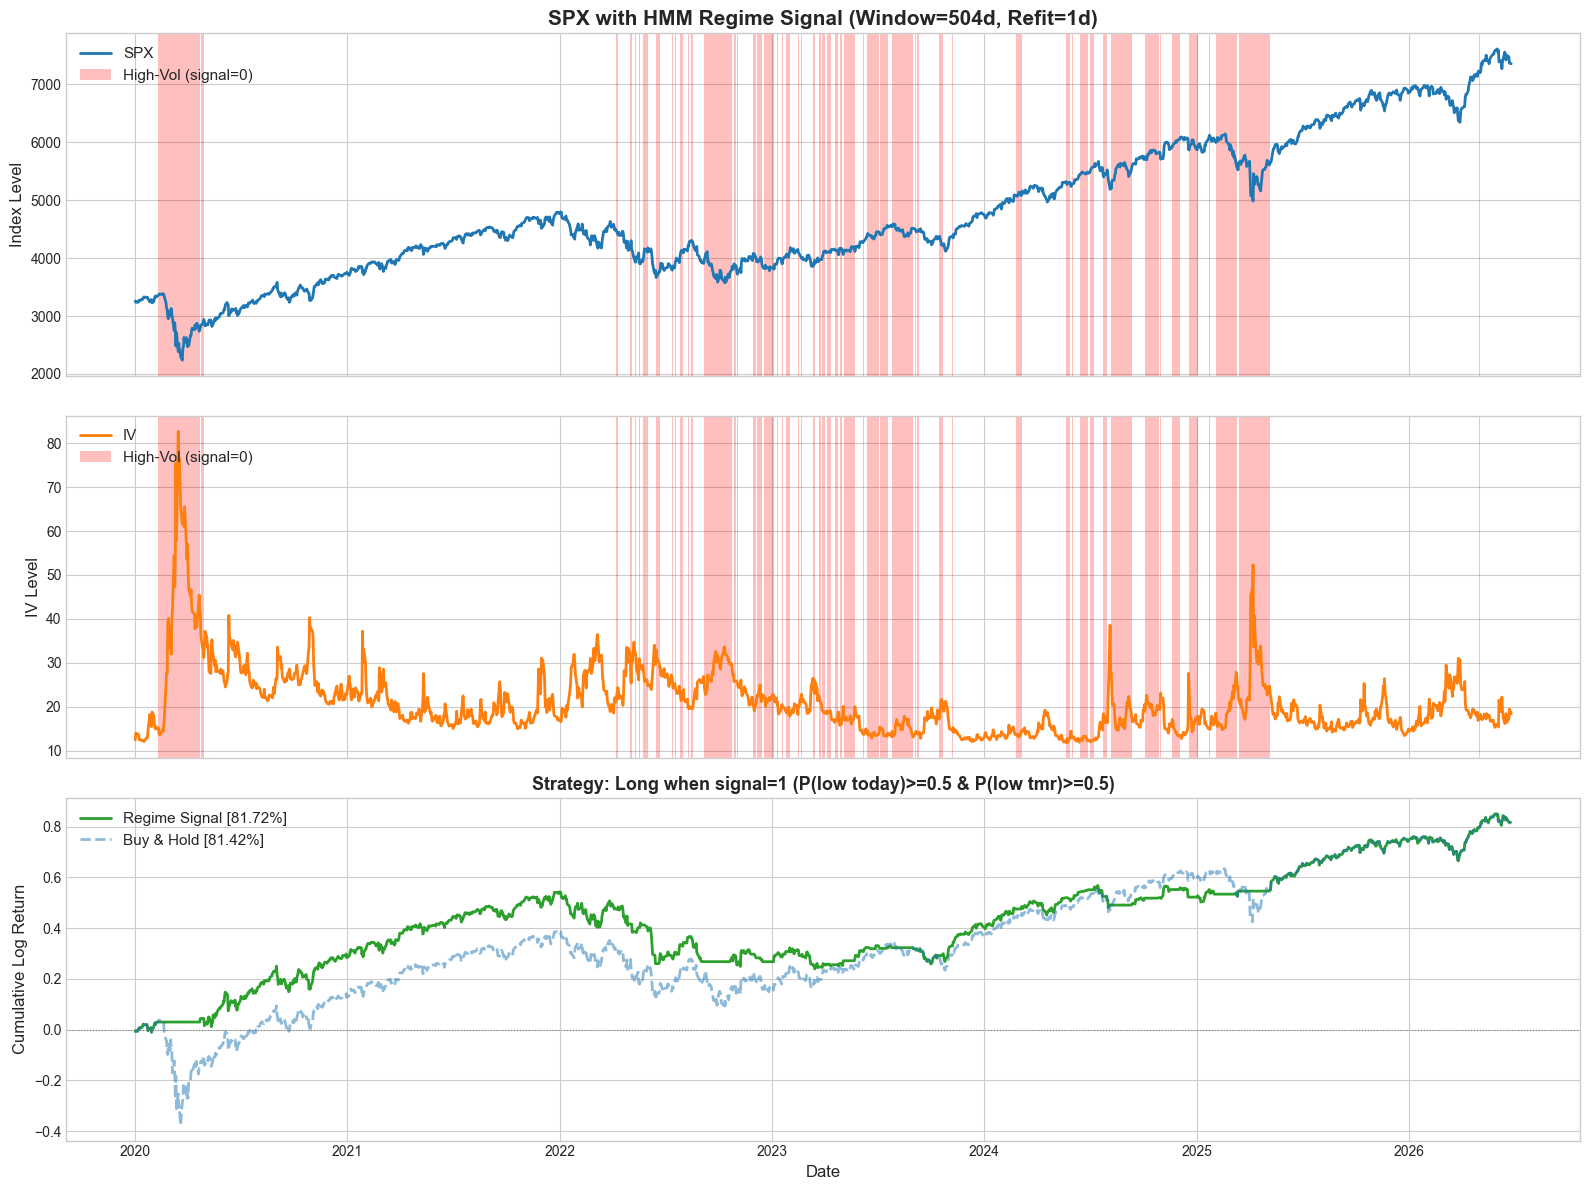

SPX | In-market: 75.1% | Strategy Return: 81.72% | B&H: 81.42%
SPX | low-vol, truncated | implied < |fwd return| | 1d: 16.0% | 15d: 10.6% | 22d: 9.0% | 30d: 7.4%


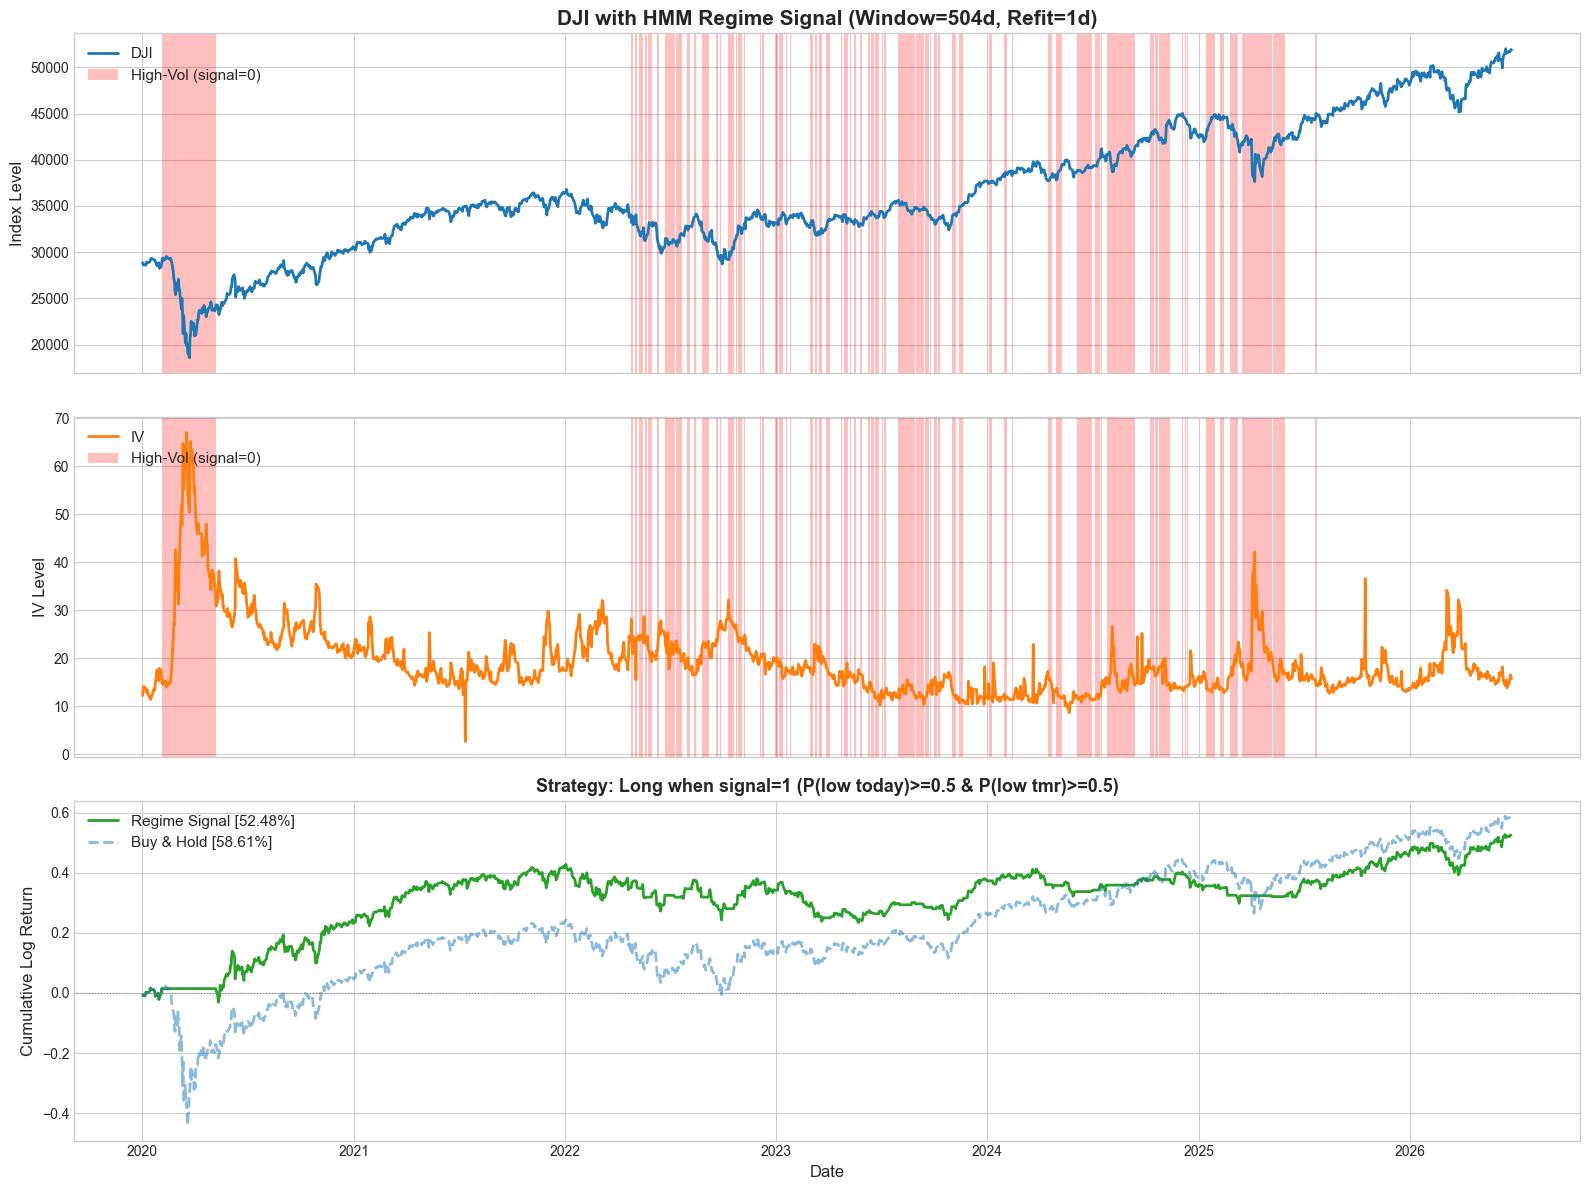

DJI | In-market: 74.4% | Strategy Return: 52.48% | B&H: 58.61%
DJI | low-vol, truncated | implied < |fwd return| | 1d: 15.9% | 15d: 8.7% | 22d: 5.6% | 30d: 4.1%


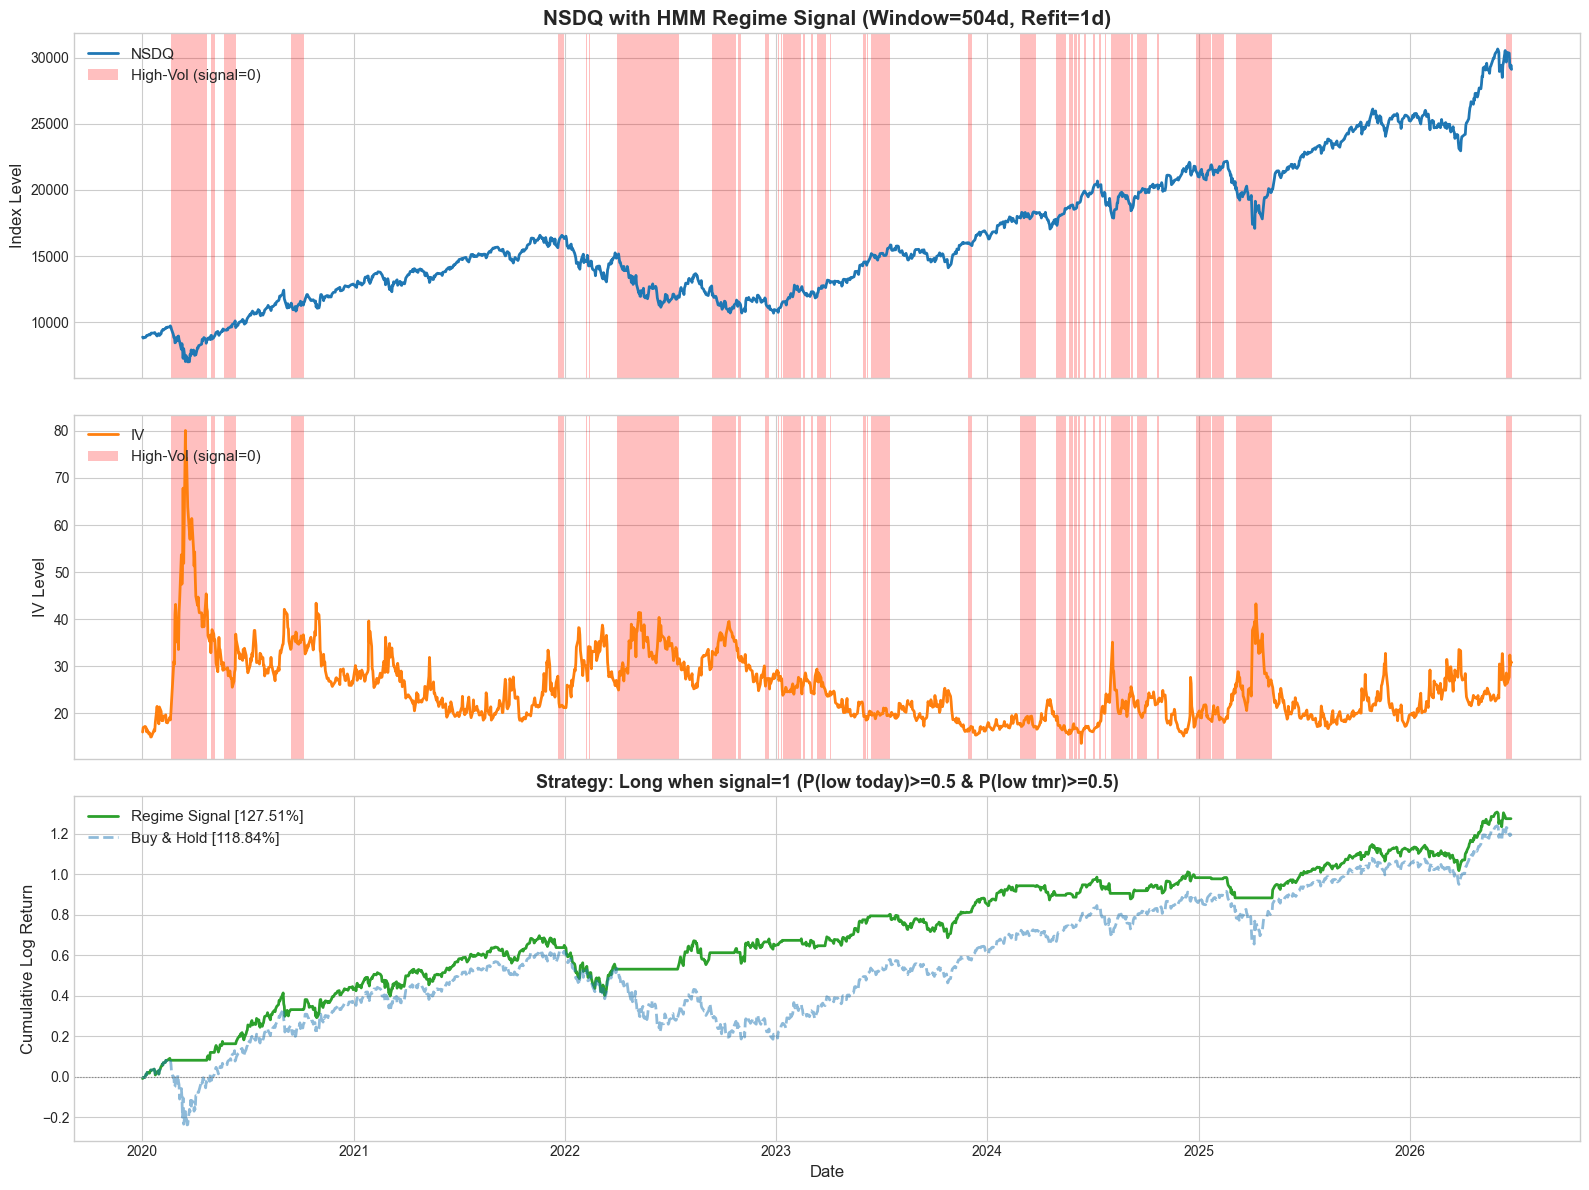

NSDQ | In-market: 73.2% | Strategy Return: 127.51% | B&H: 118.84%
NSDQ | low-vol, truncated | implied < |fwd return| | 1d: 21.1% | 15d: 17.1% | 22d: 16.3% | 30d: 14.8%


In [4]:
MOVE_HORIZONS = (1, 15, 22, 30)
def _low_vol_end_offset(regime: np.ndarray, start_idx: int, horizon: int, n: int) -> int | None:
    if regime[start_idx] != 1:
        return None

    end_offset = horizon
    for k in range(1, horizon + 1):
        j = start_idx + k
        if j >= n:
            end_offset = k - 1
            break
        if regime[j] == 0:
            end_offset = k - 1
            break

    if start_idx + end_offset >= n or end_offset <= 0:
        return None
    return end_offset


def low_vol_truncated_real_move_pct(df: pd.DataFrame, start_idx: int, horizon: int) -> float | None:
    regime = df["Regime"].to_numpy()
    spx = df["UNDERLY"].to_numpy()
    end_offset = _low_vol_end_offset(regime, start_idx, horizon, len(df))
    if end_offset is None:
        return None

    end_idx = start_idx + end_offset
    return abs(spx[end_idx] - spx[start_idx]) / spx[start_idx] * 100


def implied_lt_real_pct(df: pd.DataFrame, horizon: int, real_fn) -> float:
    implied = df["IV"].to_numpy() * np.sqrt(horizon / TRADING_DAYS)
    hits = []

    for i in range(len(df)):
        real = real_fn(df, i, horizon)
        if real is None:
            continue
        hits.append(implied[i] < real)

    if not hits:
        return float("nan")
    return float(np.mean(hits))


def print_implied_vs_real(name: str, df: pd.DataFrame) -> None:
    parts = [
        f"{h}d: {implied_lt_real_pct(df, h, low_vol_truncated_real_move_pct):.1%}"
        for h in MOVE_HORIZONS
    ]
    print(f"{name} | low-vol, truncated | implied < |fwd return| | " + " | ".join(parts))


def plot_market(name: str, df_predict: pd.DataFrame) -> None:
    future_ret = np.log(df_predict["UNDERLY"].shift(-1) / df_predict["UNDERLY"]).dropna()
    idx = future_ret.index
    regime_aligned = df_predict["Regime"].loc[idx]

    strat_ret = future_ret * (regime_aligned == 1).astype(float)
    eq_strat = strat_ret.cumsum()
    eq_bh = future_ret.cumsum()

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    ax1.plot(df_predict.index, df_predict["UNDERLY"], color="#1f77b4", linewidth=2, label=f"{name}")
    for j in range(len(df_predict) - 1):
        if df_predict["Regime"].iloc[j] == 0:
            ax1.axvspan(df_predict.index[j], df_predict.index[j + 1], color="red", alpha=0.25, lw=0)
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.set_title(
        f"{name} with HMM Regime Signal (Window={TRAIN_WINDOW_DAYS}d, Refit={REFIT_EVERY_DAYS}d)",
        fontsize=15,
        fontweight="bold",
    )
    ax1.set_ylabel("Index Level", fontsize=12)
    ax1.legend(
        handles=[
            plt.Line2D([0], [0], color="#1f77b4", lw=2, label=name),
            Patch(facecolor="red", alpha=0.25, label="High-Vol (signal=0)"),
        ],
        loc="upper left",
        fontsize=11,
    )

    ax2.plot(df_predict.index, df_predict["IV"], color="#ff7f0e", linewidth=2, label="IV")
    for j in range(len(df_predict) - 1):
        if df_predict["Regime"].iloc[j] == 0:
            ax2.axvspan(df_predict.index[j], df_predict.index[j + 1], color="red", alpha=0.25, lw=0)
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax2.set_ylabel("IV Level", fontsize=12)
    ax2.legend(
        handles=[
            plt.Line2D([0], [0], color="#ff7f0e", lw=2, label="IV"),
            Patch(facecolor="red", alpha=0.25, label="High-Vol (signal=0)"),
        ],
        loc="upper left",
        fontsize=11,
    )

    ax3.plot(eq_strat.index, eq_strat, color="#2ca02c", linewidth=2, label=f"Regime Signal [{eq_strat.iloc[-1]:.2%}]")
    ax3.plot(
        eq_bh.index,
        eq_bh,
        color="#1f77b4",
        linewidth=2,
        alpha=0.5,
        linestyle="--",
        label=f"Buy & Hold [{eq_bh.iloc[-1]:.2%}]",
    )
    ax3.xaxis.set_major_locator(mdates.YearLocator())
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax3.set_title(
        f"Strategy: Long when signal=1 (P(low today)>={LOW_VOL_PROB_THRESHOLD} & "
        f"P(low tmr)>={LOW_VOL_TMR_THRESHOLD})",
        fontsize=13,
        fontweight="bold",
    )
    ax3.set_xlabel("Date", fontsize=12)
    ax3.set_ylabel("Cumulative Log Return", fontsize=12)
    ax3.axhline(y=0.0, color="gray", linewidth=0.8, linestyle=":")
    ax3.legend(loc="upper left", fontsize=11)

    plt.tight_layout()
    plt.show()

    print(
        f"{name} | In-market: {regime_aligned.mean():.1%} | "
        f"Strategy Return: {eq_strat.iloc[-1]:.2%} | B&H: {eq_bh.iloc[-1]:.2%}"
    )
    print_implied_vs_real(name, df_predict)


for name, df_predict in results_by_market.items():
    plot_market(name, df_predict)
